<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/Hierarchical_un.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully!
Shape: (117999, 8)

First 5 Rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS      12.0   
1  489434    79323P                   PINK CHERRY LIGHTS      12.0   
2  489434    79323W                  WHITE CHERRY LIGHTS      12.0   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE       48.0   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX      24.0   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

After Cleaning:
Rows: 85089

Customer Data:
   Customer ID  Quantity  TotalAmount
0      12346.0      51.0       230.55
1      12358.0     309.0     

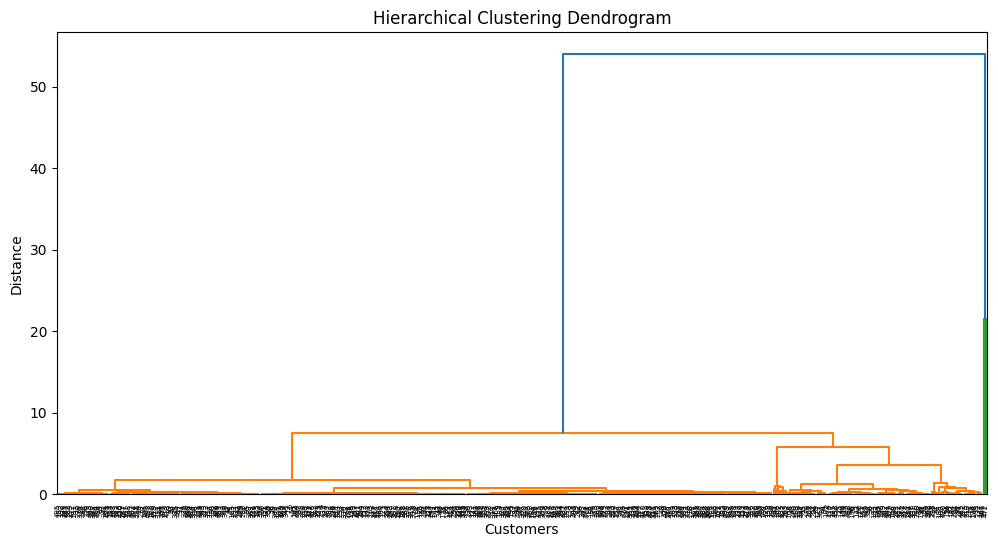


Clustered Customer Data:
    Customer ID  Quantity  TotalAmount  Cluster
0       12346.0      51.0       230.55        1
1       12358.0     309.0      1429.83        1
2       12359.0     713.0      1176.63        1
3       12360.0     100.0       118.00        1
4       12361.0      45.0       109.20        1
5       12362.0       1.0       130.00        1
6       12369.0     209.0       348.32        1
7       12370.0     172.0       562.96        1
8       12371.0     252.0       607.68        1
9       12373.0     208.0       437.90        1
10      12380.0     618.0      3217.30        1
11      12389.0      67.0       164.85        1
12      12391.0     294.0       750.49        1
13      12396.0     591.0       931.43        1
14      12399.0     219.0       205.98        1
15      12402.0      87.0       191.70        1
16      12404.0       1.0        63.24        1
17      12406.0     452.0       881.20        1
18      12416.0     132.0       202.56        1
19      12417.

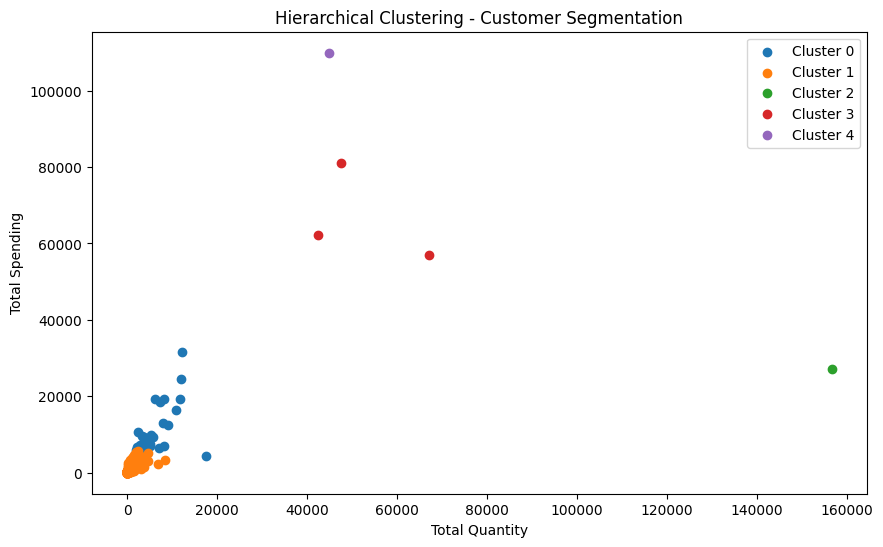


HIERARCHICAL CLUSTERING COMPLETED

Total Customers: 1860

Number of Clusters: 5


In [5]:
# ============================================
# HIERARCHICAL CLUSTERING
# Online Retail Customer Segmentation
# Unsupervised Machine Learning
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv(
    "online_retail_II.csv",
    encoding="ISO-8859-1"
)

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# ============================================
# 2. DATA CLEANING
# ============================================

# Remove rows without Customer ID

df = df.dropna(subset=["Customer ID"])

# Remove cancelled transactions

df = df[
    ~df["Invoice"].astype(str).str.startswith("C")
]

# Remove invalid quantities and prices

df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

print("\nAfter Cleaning:")
print("Rows:", len(df))

# ============================================
# 3. CREATE TOTAL SPENDING
# ============================================

df["TotalAmount"] = df["Quantity"] * df["Price"]

# ============================================
# 4. CUSTOMER LEVEL DATA
# ============================================

customer_data = df.groupby("Customer ID").agg({

    "Quantity": "sum",

    "TotalAmount": "sum"

}).reset_index()

print("\nCustomer Data:")
print(customer_data.head())

# ============================================
# 5. SELECT FEATURES
# ============================================

X = customer_data[
    [
        "Quantity",
        "TotalAmount"
    ]
]

# ============================================
# 6. FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================
# 7. DENDROGRAM
# ============================================

# Use a sample for faster visualization

sample_size = min(500, len(X_scaled))

X_sample = X_scaled[:sample_size]

linked = linkage(
    X_sample,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linked
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Distance")

plt.show()

# ============================================
# 8. APPLY HIERARCHICAL CLUSTERING
# ============================================

model = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

customer_data["Cluster"] = model.fit_predict(
    X_scaled
)

# ============================================
# 9. DISPLAY CLUSTERS
# ============================================

print("\nClustered Customer Data:")

print(
    customer_data.head(20)
)

# ============================================
# 10. CLUSTER SUMMARY
# ============================================

cluster_summary = customer_data.groupby(
    "Cluster"
).agg({

    "Quantity": "mean",

    "TotalAmount": "mean"

})

print("\nCluster Summary:")

print(cluster_summary)

# ============================================
# 11. CLUSTER COUNT
# ============================================

print("\nNumber of Customers in Each Cluster:")

print(
    customer_data["Cluster"]
    .value_counts()
    .sort_index()
)

# ============================================
# 12. VISUALIZE CLUSTERS
# ============================================

plt.figure(figsize=(10, 6))

for cluster in sorted(
    customer_data["Cluster"].unique()
):

    cluster_data = customer_data[
        customer_data["Cluster"] == cluster
    ]

    plt.scatter(

        cluster_data["Quantity"],

        cluster_data["TotalAmount"],

        label=f"Cluster {cluster}"

    )

plt.xlabel("Total Quantity")

plt.ylabel("Total Spending")

plt.title(
    "Hierarchical Clustering - Customer Segmentation"
)

plt.legend()

plt.show()

# ============================================
# 13. FINAL RESULT
# ============================================

print("\n====================================")
print("HIERARCHICAL CLUSTERING COMPLETED")
print("====================================")

print("\nTotal Customers:",
      len(customer_data))

print("\nNumber of Clusters:",
      customer_data["Cluster"].nunique())